In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd
import json

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma
from collections import defaultdict

In [2]:
import importlib

import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [5]:
path = 'Data/20251001/'

with open(f"{path}/config.json", 'r') as f:
    cfg = json.load(f)
timepoints  = cfg['timepoints']
zarr_names  = cfg['zarr_names']
wells       = cfg['wells']
rounds      = cfg['rounds']
times_dic   = cfg['times_dic'] 
annotation_names = cfg['annotation_names']

mesh_table = pd.read_csv(f'{path}/day3p5_goodmeshes.csv', sep=';')

In [6]:
# state an order 
correct_order = list(annotation_names.keys())

def load(save_path, ts):
    m = FateMarkers()
    m.load_results(save_path)
    frac = m.compute_recon_quality()
    hks_coeffs = m.compute_hks_for_new_times(ts) 
    A = m.mass_matrix.diagonal().sum()
    indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 
    return m.coeffs_fm[:, indices], hks_coeffs, frac, A 

In [12]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = []
areas = [] 

ts = [1, 4, 25, 100]


wells = mesh_table['well']
labels = mesh_table['label']
zarr_name = zarr_names['day3p5']
round_name = rounds['day3p5']

for well, label in tqdm(zip(wells, labels)):
    well_parts = well.split('_')
    well_path = f"{path}/fractal_output/{well_parts[0]}/{zarr_name}/{well_parts[1][0]}/{well_parts[1][1:]}/{round_name}/"
    save_path = f"{well_path}/fm_data/{label}"
    if os.path.exists(save_path + '_coeffs.npz'):
        try: 
            c1, c2, frac, A  = load(save_path, ts)
            coeffs_fm.append(c1)
            coeffs_hks.append(c2)
            times.append(well_parts[0][3:6])
            fracs.append(frac)
            areas.append(A)
        except Exception as e:
            print(f"Error loading {save_path}: {e}")

29it [00:02, 15.12it/s]

Error loading Data/20251001//fractal_output/day3p5/r0.zarr/A/03/0_fused_zillum_registered//fm_data/22: 'modes is not a file in the archive'


71it [00:05, 13.50it/s]


In [13]:
threshold = np.percentile(fracs, 100)
recon_mask = np.array(fracs) < threshold
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]
filtered_areas = np.array(areas)[recon_mask]
coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]

In [14]:
coeffs = np.concatenate([np.array(coeffs_fm_filtered), filtered_hks], axis=-1)

hks_names = [f'hks-{ts[i]}' for i in range(filtered_hks.shape[-1])]
names = correct_order + hks_names 
print(names)

['lgr', 'chroma', 'cycd', 'muc', 'aldob', 'gluc', 'cyca', 'agr', 'sero', 'lyz', 'hks-1', 'hks-4', 'hks-25', 'hks-100']


In [15]:
import math

def plot_matrices(matrices, title='Mutual Information', cmap='viridis'): 

    # Loop over all matrices for each timepoint
    unique_times_list = np.unique(times)
    n_timepoints = len(unique_times_list)

    short_names = names 

    # Calculate number of rows needed for 2 columns
    n_cols = 4
    n_rows = math.ceil(n_timepoints / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
    axes = axes.flatten()  # Flatten in case axes is 2D

    if cmap == 'PiYG' or cmap == 'bwr': 
        vmax = max(np.max(matrices), -np.min(matrices))
        vmin = -vmax
    if cmap == 'viridis': 
        vmin = None
        vmax = None

    for idx, (mi_matrix, timepoint) in enumerate(zip(matrices, unique_times_list)):
        n_features = mi_matrix.shape[0]
        
        # Plot 2: Without diagonal elements
        mask = np.eye(n_features, dtype=bool)
        mi_matrix_masked = np.copy(mi_matrix)
        mi_matrix_masked[mask] = np.nan

        im2 = axes[idx].imshow(mi_matrix_masked, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        plt.colorbar(im2, ax=axes[idx], label=f'{title}')
        axes[idx].set_xticks(ticks=np.arange(n_features))
        axes[idx].set_xticklabels(short_names, rotation=90, ha='right')
        axes[idx].set_yticks(ticks=np.arange(n_features))
        axes[idx].set_yticklabels(short_names)
        axes[idx].set_title(f'{title} (no diagonal) - Day {timepoint}')

    # Hide any unused subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [10]:
ksg = KSGEstimator()

coeffs_rescaled = np.empty_like(coeffs) 

for i in range(coeffs.shape[-1]):
    scaler = StandardScaler()
    coeffs_rescaled[:, :, i] = scaler.fit_transform(coeffs[:, :, i])

mi_matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    mi_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs_rescaled[mask, :, :] 
    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 

            X = np.copy(masked_coeffs[:, 1:, i])
            Y = np.copy(masked_coeffs[:, 1:, j])
            mi_matrix[i, j] = ksg.mutual_information(X, Y, method=2)
    mi_matrices.append(mi_matrix)


41 1p5
30 2
41 2p5
49 3
35 3p5
33 4
58 4p5


In [131]:
np.savez('sim/fm_coeffs_wo_encoding.npz', 
         filtered_time=filtered_times,
         coeffs=coeffs, 
         names=names, 
         mi=np.array(matrices)
         )

np.save('sim/mi.npy', np.array(matrices))


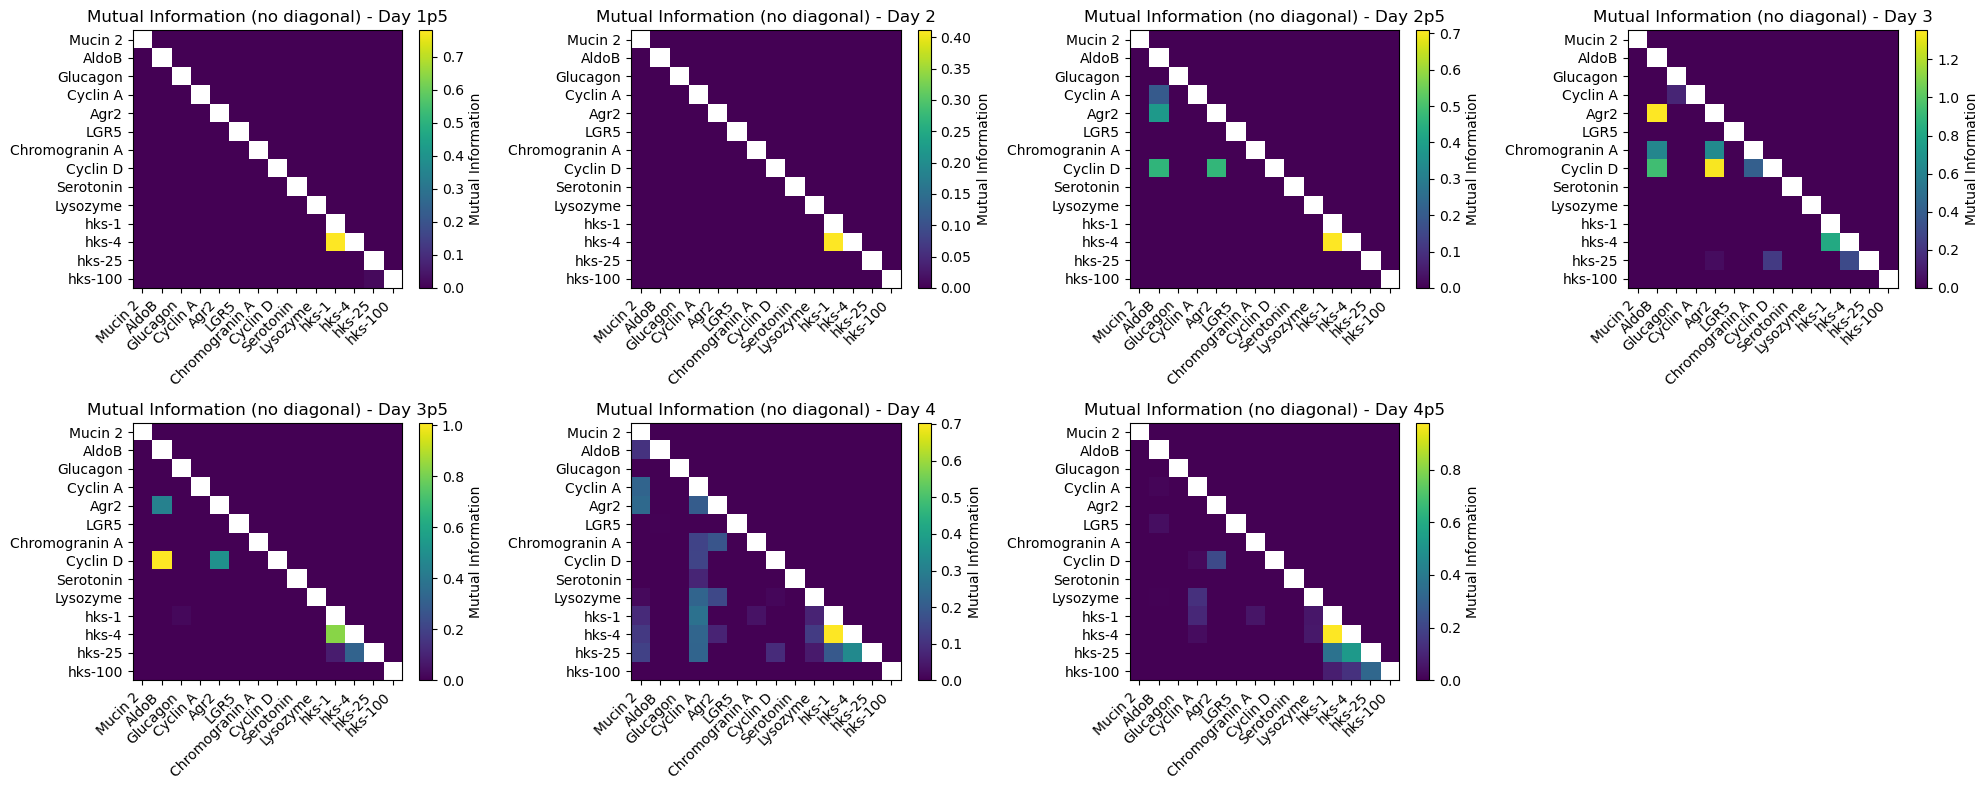

In [11]:
plot_matrices(mi_matrices)

In [16]:
def compute_corr(X, Y, A):
    corr = np.sum(np.sum(X * Y, axis=1)/A)/X.shape[0]
    x_var = np.sum(np.sum(X * X, axis=1)/A)/X.shape[0] 
    y_var = np.sum(np.sum(Y * Y, axis=1)/A)/X.shape[0] 

    if x_var == 0 or y_var == 0:
        return 0
    return corr/np.sqrt(x_var*y_var)

In [17]:
corr_matrices = [] 
for t in np.unique(times): 
    mask = (filtered_times == t) 
    print(int(np.sum(mask)), t)
    corr_matrix = np.zeros((coeffs.shape[-1], coeffs.shape[-1]))
    masked_coeffs = coeffs[mask, :, :] 


    for i in range(coeffs.shape[-1]): 
        for j in range(0, i+1): 
            X = np.copy(masked_coeffs[:, 1:, i])
            Y = np.copy(masked_coeffs[:, 1:, j])
            corr_matrix[i, j] = compute_corr(X, Y, filtered_areas[mask])
            corr_matrix[j, i] = corr_matrix[i, j]
    corr_matrices.append(corr_matrix)

69 3p5


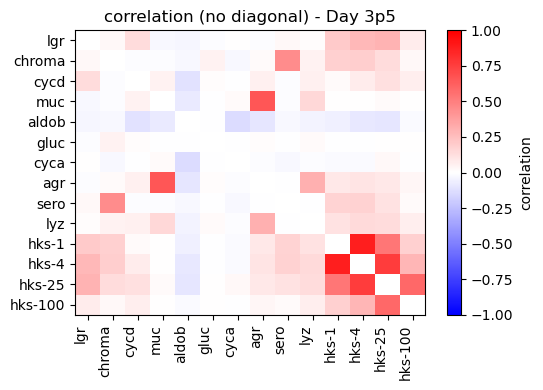

In [18]:
plot_matrices(corr_matrices, title='correlation', cmap='bwr')

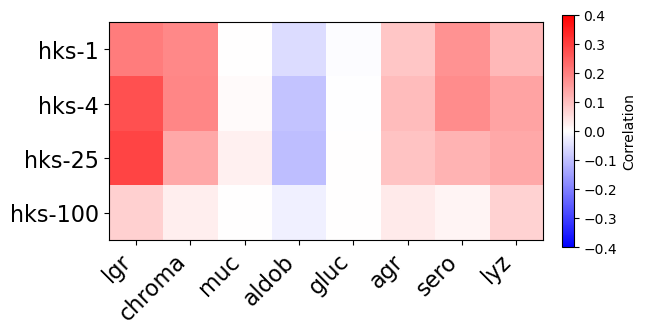

In [19]:
x_axis = ['lgr', 'chroma', 'muc', 'aldob', 'gluc', 'agr', 'sero', 'lyz']
y_axis = ['hks-1', 'hks-4', 'hks-25', 'hks-100']

# plot heatmap with the selected names 
x_indices = [names.index(name) for name in x_axis]
y_indices = [names.index(name) for name in y_axis]

# Create a new matrix with the selected rows and columns
selected_corr_matrix = corr_matrices[0][np.ix_(y_indices, x_indices)]

# Plot the heatmap
plt.figure(figsize=(6, 5))
plt.imshow(selected_corr_matrix, cmap='bwr', vmin=-0.4, vmax=0.4)
plt.colorbar(label='Correlation', fraction=0.025, pad=0.04)
plt.xticks(ticks=np.arange(len(x_axis)), labels=x_axis, rotation=45, ha='right', fontsize=16)
plt.yticks(ticks=np.arange(len(y_axis)), labels=y_axis, fontsize=16)
plt.show()